# Базовые модели и их сравнение

Сравниваются следующие архитектуры:

1. Simple CNN
2. ResNet18
3. MobileNetV2
4. EfficientNet-B0


## Импорты

In [ ]:
import os
import json
import numpy as np
import pandas as pd
from datetime import datetime
import time
import copy
import sys

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import (
    resnet18, ResNet18_Weights,
    mobilenet_v2, MobileNet_V2_Weights,
    efficientnet_b0, EfficientNet_B0_Weights
)

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.models.training import CornDiseaseDataset, train_one_epoch, evaluate, make_resnet


In [ ]:
SPLITS_DIR = "../splits"

df_train = pd.read_csv(f"{SPLITS_DIR}/train.csv")
df_val   = pd.read_csv(f"{SPLITS_DIR}/val.csv")
df_test  = pd.read_csv(f"{SPLITS_DIR}/test.csv")

# Восстанавливаем CLASSES и CLASS_TO_IDX из данных
CLASSES      = sorted(df_train['label'].unique().tolist())
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
NUM_CLASSES  = len(CLASSES)

print(f"Классы: {CLASSES}")
print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

with open("../artifacts/class_mapping.json", "w") as f:
    json.dump({"classes": CLASSES, "class_to_idx": CLASS_TO_IDX}, f, indent=2)


class SimpleCNN(nn.Module):
    """Простая CNN с нуля — служит нижней планкой (lower bound)."""
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d((4, 4))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))
    


def run_experiment(model, model_name, num_epochs, optimizer, scheduler=None,
                   criterion=None, device='cpu'):
    """
    Обучает модель, сохраняет лучшие веса и возвращает историю метрик.
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    best_weights = None
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"\n{'='*60}\n{model_name}\n{'='*60}")

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc, elapsed = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, _, _  = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)

        if scheduler:
            scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch:2d}/{num_epochs} | "
              f"Train {tr_acc:.4f} (loss {tr_loss:.4f}) | "
              f"Val {val_acc:.4f} (loss {val_loss:.4f}) | "
              f"{elapsed:.1f}s")

    # Загружаем лучшие веса и оцениваем на тесте
    model.load_state_dict(best_weights)
    _, test_acc, preds, labels = evaluate(model, test_loader, criterion, device)

    print(f"\n{model_name}: best val_acc={best_val_acc:.4f}, test_acc={test_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(labels, preds, target_names=CLASSES))

    # Сохраняем веса
    save_path = f"../artifacts/models/{model_name.replace(' ', '_').lower()}.pth"
    torch.save({
        'model_state_dict': best_weights,
        'class_to_idx': CLASS_TO_IDX,
        'val_acc': best_val_acc,
        'test_acc': test_acc,
    }, save_path)

    return history, test_acc, preds, labels

IMG_SIZE = 224
BATCH_SIZE = 64

# ImageNet статистика нормализации
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset = CornDiseaseDataset(df_train, CLASS_TO_IDX, transform=train_transforms)
val_dataset   = CornDiseaseDataset(df_val,   CLASS_TO_IDX, transform=val_test_transforms)
test_dataset  = CornDiseaseDataset(df_test,  CLASS_TO_IDX, transform=val_test_transforms)

loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=2,
                     pin_memory=True, persistent_workers=True)
train_loader = DataLoader(train_dataset, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_dataset,   shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_dataset,  shuffle=False, **loader_kwargs)

Классы: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
  Blight: 1146 изображений
  Common_Rust: 1306 изображений
  Gray_Leaf_Spot: 574 изображений
  Healthy: 1162 изображений

Train: 3350 | Val: 419 | Test: 419
Train batches: 53 | Val: 7 | Test: 7


In [4]:
print("="*70)
print("Сравнение четырёх моделей")
print("Simple CNN | ResNet18 | MobileNetV2 | EfficientNet-B0")
print("="*70)

criterion = nn.CrossEntropyLoss()
results   = {}   # {model_name: test_acc}
histories = {}   # {model_name: history}
all_preds_dict  = {}
all_labels_dict = {}
NUM_EPOCHS = 15


Сравнение четырёх моделей
Simple CNN | ResNet18 | MobileNetV2 | EfficientNet-B0


## Simple CNN

In [ ]:
# ── МОДЕЛЬ 1: Simple CNN (обучается с нуля, нижняя планка) ──────────────────

model_cnn = SimpleCNN(num_classes=NUM_CLASSES, dropout=0.3).to(device)
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=1e-3)
scheduler_cnn = optim.lr_scheduler.CosineAnnealingLR(optimizer_cnn, T_max=NUM_EPOCHS)

history_cnn, acc_cnn, preds_cnn, labels_cnn = run_experiment(
    model_cnn, "Simple CNN", NUM_EPOCHS,
    optimizer_cnn, scheduler_cnn, criterion, device
)
results['Simple CNN'] = acc_cnn
histories['Simple CNN'] = history_cnn
all_preds_dict['Simple CNN']  = preds_cnn
all_labels_dict['Simple CNN'] = labels_cnn



Simple CNN
Epoch  1/15 | Train 0.7675 (loss 0.5593) | Val 0.8234 (loss 0.4186) | 23.6s
Epoch  2/15 | Train 0.8409 (loss 0.3793) | Val 0.8520 (loss 0.3764) | 21.6s
Epoch  3/15 | Train 0.8615 (loss 0.3381) | Val 0.8735 (loss 0.3336) | 21.4s
Epoch  4/15 | Train 0.8690 (loss 0.3288) | Val 0.8711 (loss 0.3167) | 25.9s
Epoch  5/15 | Train 0.8803 (loss 0.2967) | Val 0.8950 (loss 0.2534) | 21.4s
Epoch  6/15 | Train 0.8851 (loss 0.2838) | Val 0.8902 (loss 0.2598) | 20.3s
Epoch  7/15 | Train 0.8896 (loss 0.2715) | Val 0.8998 (loss 0.2503) | 22.0s
Epoch  8/15 | Train 0.9003 (loss 0.2489) | Val 0.9189 (loss 0.2387) | 21.4s
Epoch  9/15 | Train 0.9069 (loss 0.2339) | Val 0.9141 (loss 0.2378) | 21.5s
Epoch 10/15 | Train 0.9140 (loss 0.2188) | Val 0.9236 (loss 0.2133) | 20.2s
Epoch 11/15 | Train 0.9096 (loss 0.2157) | Val 0.9165 (loss 0.2188) | 22.4s
Epoch 12/15 | Train 0.9218 (loss 0.2039) | Val 0.9141 (loss 0.2155) | 27.3s
Epoch 13/15 | Train 0.9242 (loss 0.1930) | Val 0.9165 (loss 0.2089) | 21.0s


## ResNet18

In [ ]:
# ── МОДЕЛЬ 2: ResNet18 (полный fine-tune, предобучена на ImageNet) ──────────

model_resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, NUM_CLASSES)
model_resnet = model_resnet.to(device)

# Полный fine-tune: все слои обучаются
# lr=1e-4 (меньше, чем у CNN), чтобы не разрушить pretrained веса backbone
optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=1e-4)
scheduler_resnet = optim.lr_scheduler.CosineAnnealingLR(optimizer_resnet, T_max=NUM_EPOCHS)

history_resnet, acc_resnet, preds_resnet, labels_resnet = run_experiment(
    model_resnet, "ResNet18", NUM_EPOCHS,
    optimizer_resnet, scheduler_resnet, criterion, device
)
results['ResNet18'] = acc_resnet
histories['ResNet18'] = history_resnet
all_preds_dict['ResNet18']  = preds_resnet
all_labels_dict['ResNet18'] = labels_resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]



ResNet18
Epoch  1/15 | Train 0.8884 (loss 0.2909) | Val 0.9523 (loss 0.1417) | 22.1s
Epoch  2/15 | Train 0.9519 (loss 0.1327) | Val 0.9523 (loss 0.1493) | 21.7s
Epoch  3/15 | Train 0.9621 (loss 0.1009) | Val 0.9547 (loss 0.1206) | 21.7s
Epoch  4/15 | Train 0.9666 (loss 0.0901) | Val 0.9594 (loss 0.1160) | 22.3s
Epoch  5/15 | Train 0.9773 (loss 0.0689) | Val 0.9690 (loss 0.0958) | 22.6s
Epoch  6/15 | Train 0.9785 (loss 0.0570) | Val 0.9499 (loss 0.1328) | 22.5s
Epoch  7/15 | Train 0.9875 (loss 0.0416) | Val 0.9714 (loss 0.0919) | 22.0s
Epoch  8/15 | Train 0.9866 (loss 0.0399) | Val 0.9714 (loss 0.1020) | 21.2s
Epoch  9/15 | Train 0.9919 (loss 0.0284) | Val 0.9737 (loss 0.0830) | 21.2s
Epoch 10/15 | Train 0.9925 (loss 0.0233) | Val 0.9714 (loss 0.0933) | 22.1s
Epoch 11/15 | Train 0.9952 (loss 0.0216) | Val 0.9761 (loss 0.0806) | 22.5s
Epoch 12/15 | Train 0.9961 (loss 0.0151) | Val 0.9714 (loss 0.0935) | 22.3s
Epoch 13/15 | Train 0.9961 (loss 0.0134) | Val 0.9761 (loss 0.0810) | 21.4s
Ep

## MobileNetV2

In [ ]:
# ── МОДЕЛЬ 3: MobileNetV2 (полный fine-tune, предобучена на ImageNet) ───────

model_mobile = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
model_mobile.classifier[1] = nn.Linear(model_mobile.classifier[1].in_features, NUM_CLASSES)
model_mobile = model_mobile.to(device)

# Полный fine-tune: все слои обучаются
# lr=1e-4 — стандартный выбор для fine-tune pretrained моделей
optimizer_mobile = optim.Adam(model_mobile.parameters(), lr=1e-4)
scheduler_mobile = optim.lr_scheduler.CosineAnnealingLR(optimizer_mobile, T_max=NUM_EPOCHS)

history_mobile, acc_mobile, preds_mobile, labels_mobile = run_experiment(
    model_mobile, "MobileNetV2", NUM_EPOCHS,
    optimizer_mobile, scheduler_mobile, criterion, device
)
results['MobileNetV2'] = acc_mobile
histories['MobileNetV2'] = history_mobile
all_preds_dict['MobileNetV2']  = preds_mobile
all_labels_dict['MobileNetV2'] = labels_mobile


MobileNetV2
Epoch  1/15 | Train 0.8740 (loss 0.3548) | Val 0.9260 (loss 0.1597) | 23.3s
Epoch  2/15 | Train 0.9451 (loss 0.1496) | Val 0.9475 (loss 0.1161) | 22.8s
Epoch  3/15 | Train 0.9621 (loss 0.1138) | Val 0.9737 (loss 0.0889) | 22.7s
Epoch  4/15 | Train 0.9630 (loss 0.0917) | Val 0.9570 (loss 0.0907) | 23.0s
Epoch  5/15 | Train 0.9690 (loss 0.0837) | Val 0.9642 (loss 0.0891) | 23.0s
Epoch  6/15 | Train 0.9779 (loss 0.0640) | Val 0.9690 (loss 0.0865) | 22.9s
Epoch  7/15 | Train 0.9797 (loss 0.0563) | Val 0.9690 (loss 0.0917) | 23.0s
Epoch  8/15 | Train 0.9845 (loss 0.0417) | Val 0.9761 (loss 0.0745) | 23.3s
Epoch  9/15 | Train 0.9857 (loss 0.0370) | Val 0.9690 (loss 0.0766) | 22.7s
Epoch 10/15 | Train 0.9896 (loss 0.0288) | Val 0.9761 (loss 0.0692) | 21.8s
Epoch 11/15 | Train 0.9922 (loss 0.0219) | Val 0.9714 (loss 0.0798) | 21.8s
Epoch 12/15 | Train 0.9937 (loss 0.0205) | Val 0.9714 (loss 0.0658) | 22.6s
Epoch 13/15 | Train 0.9958 (loss 0.0162) | Val 0.9737 (loss 0.0653) | 22.8s

## EfficientNet-B0

In [ ]:
# ── МОДЕЛЬ 4: EfficientNet-B0 (полный fine-tune, предобучена на ImageNet) ───

model_effnet = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
# EfficientNet-B0: последний классификатор — model.classifier[1]
model_effnet.classifier[1] = nn.Linear(model_effnet.classifier[1].in_features, NUM_CLASSES)
model_effnet = model_effnet.to(device)

# lr=1e-4 — стандартный выбор для full fine-tune pretrained моделей
optimizer_effnet = optim.Adam(model_effnet.parameters(), lr=1e-4)
scheduler_effnet = optim.lr_scheduler.CosineAnnealingLR(optimizer_effnet, T_max=NUM_EPOCHS)

history_effnet, acc_effnet, preds_effnet, labels_effnet = run_experiment(
    model_effnet, "EfficientNet-B0", NUM_EPOCHS,
    optimizer_effnet, scheduler_effnet, criterion, device
)
results['EfficientNet-B0'] = acc_effnet
histories['EfficientNet-B0'] = history_effnet
all_preds_dict['EfficientNet-B0']  = preds_effnet
all_labels_dict['EfficientNet-B0'] = labels_effnet



EfficientNet-B0
Epoch  1/15 | Train 0.8197 (loss 0.6529) | Val 0.9332 (loss 0.2047) | 24.5s
Epoch  2/15 | Train 0.9385 (loss 0.1968) | Val 0.9523 (loss 0.1404) | 24.5s
Epoch  3/15 | Train 0.9543 (loss 0.1384) | Val 0.9642 (loss 0.1087) | 24.1s
Epoch  4/15 | Train 0.9621 (loss 0.1073) | Val 0.9642 (loss 0.1014) | 24.4s
Epoch  5/15 | Train 0.9699 (loss 0.0917) | Val 0.9690 (loss 0.0927) | 24.5s
Epoch  6/15 | Train 0.9788 (loss 0.0661) | Val 0.9666 (loss 0.0867) | 24.8s
Epoch  7/15 | Train 0.9806 (loss 0.0575) | Val 0.9690 (loss 0.0878) | 24.8s
Epoch  8/15 | Train 0.9833 (loss 0.0515) | Val 0.9714 (loss 0.0966) | 24.4s
Epoch  9/15 | Train 0.9875 (loss 0.0420) | Val 0.9690 (loss 0.0940) | 24.6s
Epoch 10/15 | Train 0.9872 (loss 0.0401) | Val 0.9714 (loss 0.0953) | 26.6s
Epoch 11/15 | Train 0.9863 (loss 0.0402) | Val 0.9666 (loss 0.1031) | 23.3s
Epoch 12/15 | Train 0.9913 (loss 0.0320) | Val 0.9714 (loss 0.0973) | 23.7s
Epoch 13/15 | Train 0.9896 (loss 0.0310) | Val 0.9666 (loss 0.1005) | 2

## Сравнение моделей


Модель                      Test Acc   F1 (macro)
--------------------------------------------------
ResNet18                      0.9690       0.9591 <- лучшая
EfficientNet-B0               0.9666       0.9547
MobileNetV2                   0.9642       0.9514
Simple CNN                    0.9451       0.9283


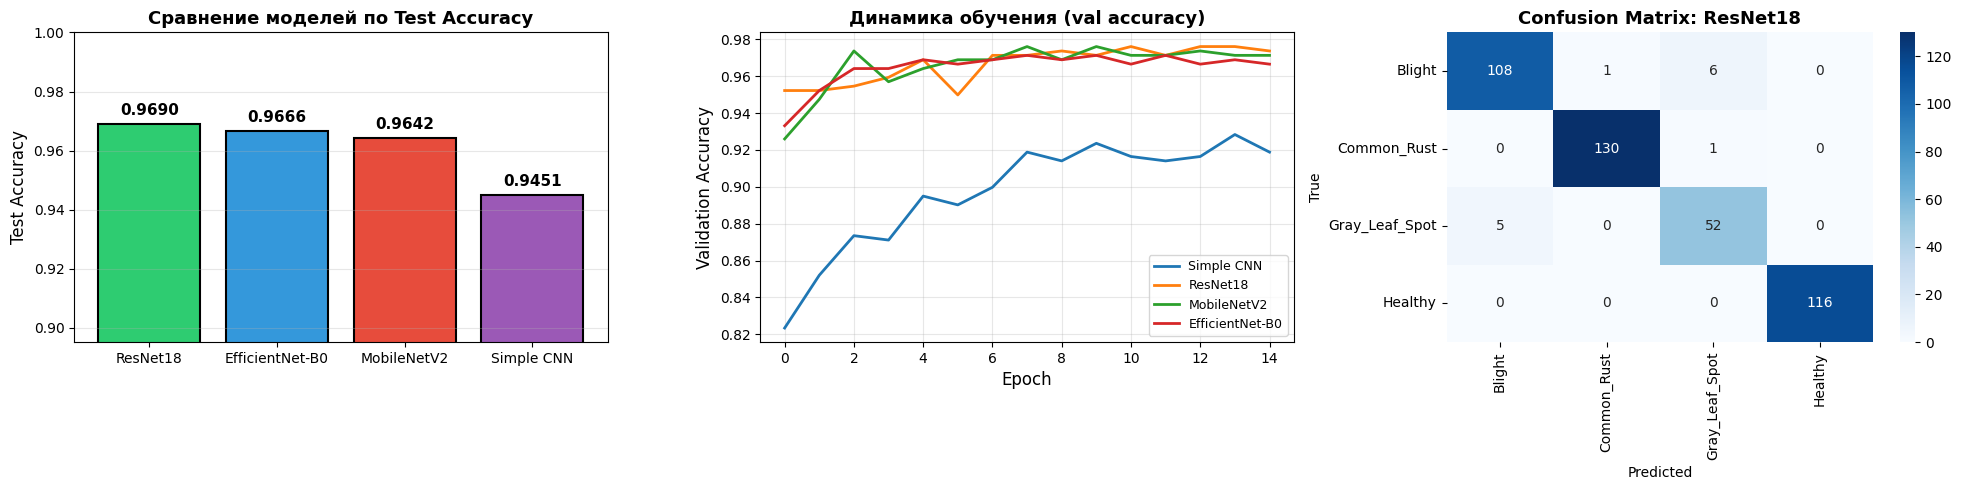


Рекомендуемая модель для экспериментов: ResNet18


In [ ]:
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)

print("\n" + "="*70)
print(f"{'Модель':<25s}  {'Test Acc':>9s}  {'F1 (macro)':>11s}")
print("-"*50)
for model_name, acc in sorted_results:
    p = all_preds_dict[model_name]
    l = all_labels_dict[model_name]
    f1 = f1_score(l, p, average='macro')
    tag = " <- лучшая" if model_name == sorted_results[0][0] else ""
    print(f"{model_name:<25s}  {acc:>9.4f}  {f1:>11.4f}{tag}")
print("="*70)

# ── График 1: Test Accuracy ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

model_names = [n for n, _ in sorted_results]
accuracies  = [a for _, a in sorted_results]
palette = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
colors  = [palette[i % len(palette)] for i in range(len(sorted_results))]

ax = axes[0]
bars = ax.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Сравнение моделей по Test Accuracy', fontsize=13, fontweight='bold')
y_min = max(0, min(accuracies) - 0.05)
ax.set_ylim(y_min, min(1.0, max(accuracies) + 0.05))
ax.grid(alpha=0.3, axis='y')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{acc:.4f}', ha='center', fontweight='bold', fontsize=11)

# ── График 2: Динамика val_acc ──
ax = axes[1]
for model_name in results.keys():
    ax.plot(histories[model_name]['val_acc'], label=model_name, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Динамика обучения (val accuracy)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── График 3: Confusion matrix лучшей модели ──
best_model_name = sorted_results[0][0]
cm = confusion_matrix(all_labels_dict[best_model_name], all_preds_dict[best_model_name])
ax = axes[2]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title(f'Confusion Matrix: {best_model_name}', fontsize=13, fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../artifacts/figures/models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Сохраняем итоговые результаты ──
summary = {
    name: {'test_acc': float(acc), 'f1_macro': float(f1_score(all_labels_dict[name], all_preds_dict[name], average='macro'))}
    for name, acc in results.items()
}
summary['best_model'] = best_model_name
with open("../artifacts/baseline_results.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"\nРекомендуемая модель для экспериментов: {best_model_name}")

# ── Сохраняем конфиг лучшей модели для experiments.ipynb ────────────────────
# В experiments.ipynb значения BASELINE будут читаться отсюда, а не хардкодиться

model_configs = {
    'Simple CNN':      dict(lr=1e-3, weight_decay=0.0, optimizer='Adam'),
    'ResNet18':         dict(lr=1e-4, weight_decay=0.0, optimizer='Adam'),
    'MobileNetV2':      dict(lr=1e-4, weight_decay=0.0, optimizer='Adam'),
    'EfficientNet-B0':  dict(lr=1e-4, weight_decay=0.0, optimizer='Adam'),
}

best_preds  = all_preds_dict[best_model_name]
best_labels = all_labels_dict[best_model_name]
gls_idx     = CLASS_TO_IDX['Gray_Leaf_Spot']
gls_f1      = f1_score(best_labels, best_preds, labels=[gls_idx], average='macro')

baseline_config = {
    'best_model_name': best_model_name,
    'test_acc':  float(results[best_model_name]),
    'f1_macro':  float(f1_score(best_labels, best_preds, average='macro')),
    'f1_gls':    float(gls_f1),
    'num_epochs': NUM_EPOCHS,
    'batch_size': BATCH_SIZE,
    'img_size':   IMG_SIZE,
    'training_config': model_configs[best_model_name],
    'all_models_results': summary,
}

with open("../artifacts/baseline_config.json", "w") as f:
    json.dump(baseline_config, f, indent=2, ensure_ascii=False)
